In [1]:
print("Alhamdullilah")

Alhamdullilah


### Credit default (decision trees)

In [28]:
import pandas as pd
import numpy as np

df = pd.read_csv("data/UCI_Credit_Card.csv")

print(df.shape)
print(df.head())
print(df.info())

(30000, 25)
   ID  LIMIT_BAL  SEX  EDUCATION  ...  PAY_AMT4  PAY_AMT5  PAY_AMT6  default
0   1    20000.0    2          2  ...       0.0       0.0       0.0        1
1   2   120000.0    2          2  ...    1000.0       0.0    2000.0        1
2   3    90000.0    2          2  ...    1000.0    1000.0    5000.0        0
3   4    50000.0    2          2  ...    1100.0    1069.0    1000.0        0
4   5    50000.0    1          2  ...    9000.0     689.0     679.0        0

[5 rows x 25 columns]
<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   ID         30000 non-null  int64  
 1   LIMIT_BAL  30000 non-null  float64
 2   SEX        30000 non-null  int64  
 3   EDUCATION  30000 non-null  int64  
 4   MARRIAGE   30000 non-null  int64  
 5   AGE        30000 non-null  int64  
 6   PAY_0      30000 non-null  int64  
 7   PAY_2      30000 non-null  int64  
 8   

In [29]:
# Understand the target
df['default'].value_counts(normalize=True)

# Basic data inspection
# Check duplicate
df.duplicated().sum()

# Check missing values
df.isnull().sum().sort_values(ascending=False).head(20)

# NUmerical stats
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,30000.0,15000.500000,8660.398374,1.0,7500.75,15000.5,22500.25,30000.0
LIMIT_BAL,30000.0,167484.322667,129747.661567,10000.0,50000.00,140000.0,240000.00,1000000.0
SEX,30000.0,1.603733,0.489129,1.0,1.00,2.0,2.00,2.0
EDUCATION,30000.0,1.853133,0.790349,0.0,1.00,2.0,2.00,6.0
MARRIAGE,30000.0,1.551867,0.521970,0.0,1.00,2.0,2.00,3.0
AGE,30000.0,35.485500,9.217904,21.0,28.00,34.0,41.00,79.0
PAY_0,30000.0,-0.016700,1.123802,-2.0,-1.00,0.0,0.00,8.0
PAY_2,30000.0,-0.133767,1.197186,-2.0,-1.00,0.0,0.00,8.0
PAY_3,30000.0,-0.166200,1.196868,-2.0,-1.00,0.0,0.00,8.0
PAY_4,30000.0,-0.220667,1.169139,-2.0,-1.00,0.0,0.00,8.0


In [30]:
# Find X and y
target = "default"

X = df.drop(columns=[target])
y = df[target]

# Remove ID column is dataframe contains
X = X.drop(columns=["ID"], errors="ignore")

print(df.shape)
print(X.shape)
print(y.shape)
X.head()

(30000, 25)
(30000, 23)
(30000,)


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
0,20000.0,2,2,1,24,2,2,-1,-1,-2,-2,3913.0,3102.0,689.0,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0
1,120000.0,2,2,2,26,-1,2,0,0,0,2,2682.0,1725.0,2682.0,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0
2,90000.0,2,2,2,34,0,0,0,0,0,0,29239.0,14027.0,13559.0,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0
3,50000.0,2,2,1,37,0,0,0,0,0,0,46990.0,48233.0,49291.0,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0
4,50000.0,1,2,1,57,-1,0,-1,0,0,0,8617.0,5670.0,35835.0,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0


In [39]:
# TT Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [40]:
# Building first decision tree
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    random_state=42
)

dt.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [41]:
y_pred = dt.predict(X_test)   # predict() -> 0 or 1
y_prob = dt.predict_proba(X_test)[:, 1]    # predict_prob() -> 0.00 to 1 in an array for each test value

In [63]:
# Evaluate decision tree
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

print("Accuracy   : ", accuracy_score(y_test, y_pred))
print("Precision  : ", precision_score(y_test, y_pred))
print("Recall     : ", recall_score(y_test, y_pred))
print("F1 Score   : ", f1_score(y_test, y_pred))
print("ROC-AUC    : ", roc_auc_score(y_test, y_pred))
print("Confusion Matrix: \n", confusion_matrix(y_test, y_pred))
print("Classification Report: \n", classification_report(y_test, y_pred))

print("Training accuracy: ", dt.score(X_train, y_train))
print("Test accuracy: ", dt.score(X_test, y_test))

dt_score = roc_auc_score(y_test, y_pred)

Accuracy   :  0.7145
Precision  :  0.36941813261163736
Recall     :  0.4114544084400904
F1 Score   :  0.3893048128342246
ROC-AUC    :  0.6060053980997798
Confusion Matrix: 
 [[3741  932]
 [ 781  546]]
Classification Report: 
               precision    recall  f1-score   support

           0       0.83      0.80      0.81      4673
           1       0.37      0.41      0.39      1327

    accuracy                           0.71      6000
   macro avg       0.60      0.61      0.60      6000
weighted avg       0.73      0.71      0.72      6000

Training accuracy:  0.8252083333333333
Test accuracy:  0.8171666666666667


#### Control tree complexity

In [50]:
depths = [2,3,4,5,7,10,15,20,25]

for depth in depths: 
    model = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42,
        min_samples_split=20,
        min_samples_leaf=10
    )
    
    model.fit(X_train, y_train)

    train_auc = roc_auc_score(
        y_train,
        model.predict_proba(X_train)[:, 1]
    )

    test_auc = roc_auc_score(
        y_test,
        model.predict_proba(X_test)[:, 1]
    )

    print(f"{depth}  {train_auc}   {test_auc}")

2  0.6941702935162518   0.6900990973978527
3  0.7336534337787752   0.7285239114340087
4  0.7485817543693387   0.7360368878214747
5  0.7656635051964206   0.7423173351829064
7  0.784238158625372   0.7506293670883626
10  0.8221807546930193   0.7353042724393899
15  0.886496547498658   0.7092003945770013
20  0.9164902886379139   0.6903686476094211
25  0.9241770770139779   0.6880653358105399


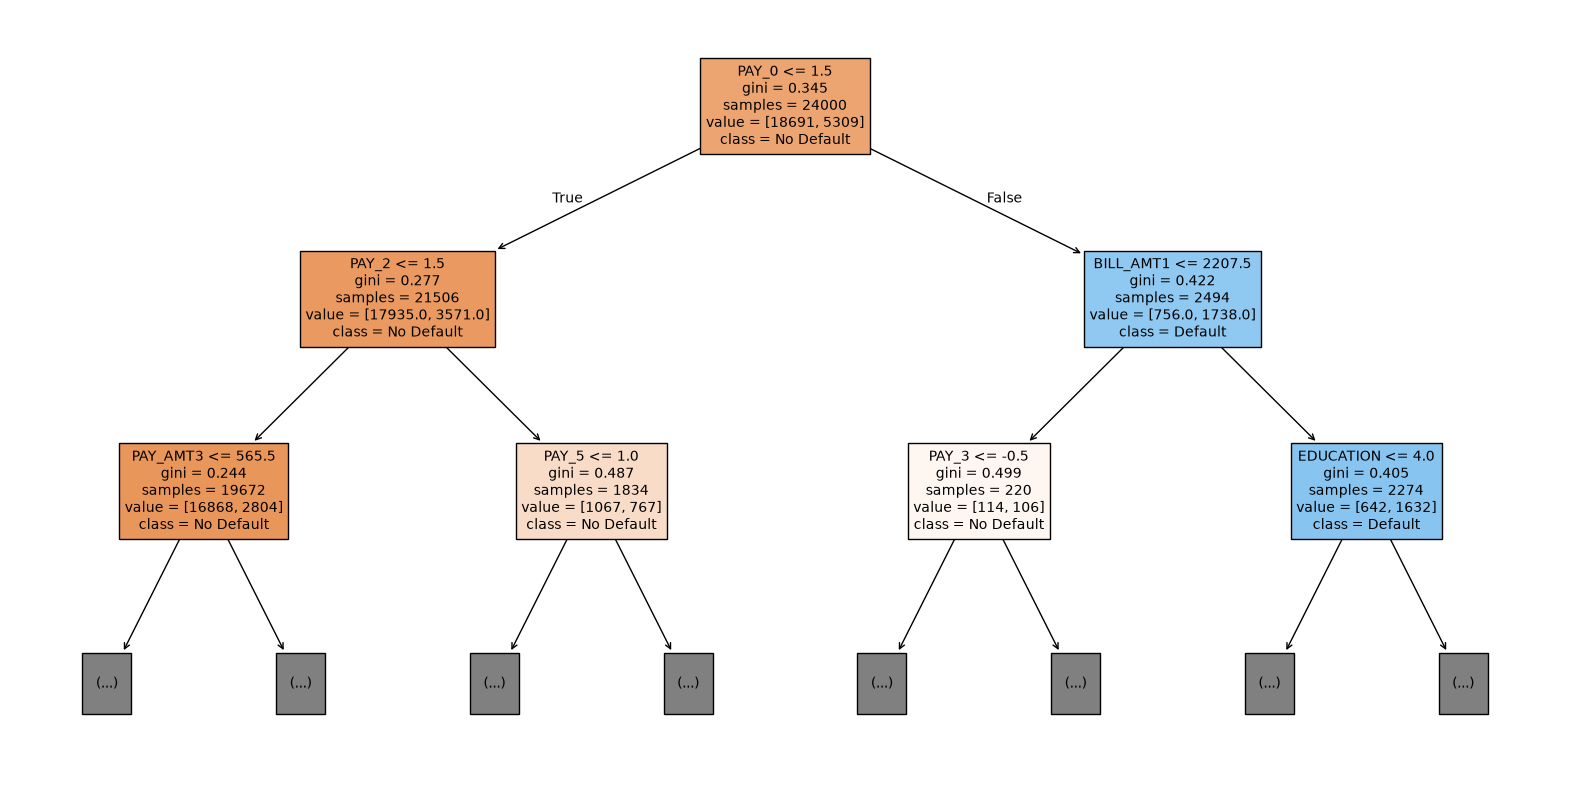

In [54]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 10))

plot_tree(
    dt,
    feature_names=X.columns,
    class_names=["No Default", "Default"],
    filled=True,
    max_depth=2
)

plt.show()

In [56]:
# Feature Importance

importance = pd.Series(
    dt.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

importance.head(15)

PAY_0        0.680061
PAY_2        0.137682
PAY_AMT3     0.043952
PAY_5        0.033120
BILL_AMT1    0.031706
LIMIT_BAL    0.021916
PAY_3        0.011477
AGE          0.008794
PAY_4        0.008470
EDUCATION    0.005236
PAY_AMT5     0.004847
PAY_AMT6     0.003816
BILL_AMT5    0.003725
PAY_AMT2     0.002729
BILL_AMT2    0.001157
dtype: float64

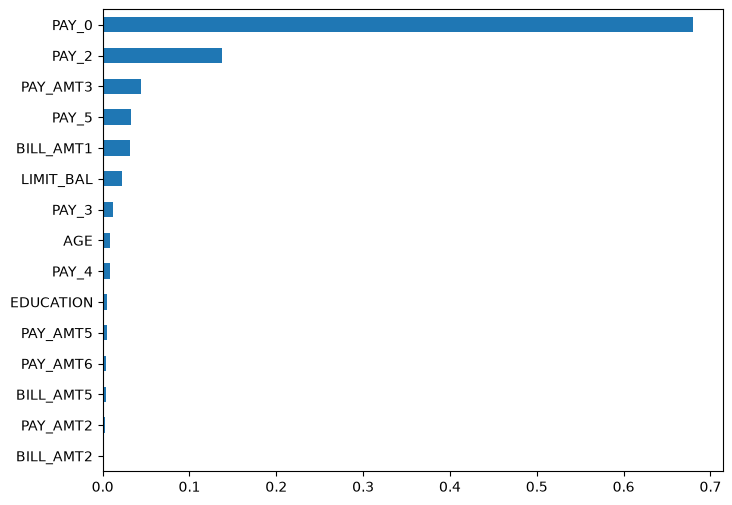

In [58]:
importance.head(15).sort_values().plot(
    kind='barh',
    figsize=(8,6)
)
plt.show()

In [59]:
# Cross Validation
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    dt,
    X,
    y,
    cv=5,
    scoring="roc_auc"
)

print(scores)
print("Mean ROC-AUC: ", scores.mean())

[0.73053934 0.72845925 0.76199644 0.76681189 0.76837372]
Mean ROC-AUC:  0.7512361282717576


In [64]:
# Introduce Ensembles
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

rf_prob = rf.predict_proba(X_test)[:, 1]

print("Random Forest ROC-AUC: ", roc_auc_score(y_test, rf_prob))
rf_score = roc_auc_score(y_test, rf_prob)

Random Forest ROC-AUC:  0.7544770895221165


In [65]:
# Gradient Boosting
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb.fit(X_train, y_train)

gb_prob = gb.predict_proba(X_test)[:, 1]
print("Gradient Boosting ROC-AUC: ", roc_auc_score(y_test, gb_prob))

gb_score = roc_auc_score(y_test, gb_prob)

Gradient Boosting ROC-AUC:  0.7756611720781782


In [66]:
# Final comparison
results= pd.DataFrame({
    "Model": [
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting"
    ],
    "ROC-AUC": [
        dt_score,
        rf_score,
        gb_score
    ]
})

print(results)

               Model   ROC-AUC
0      Decision Tree  0.606005
1      Random Forest  0.754477
2  Gradient Boosting  0.775661
